# Nonlinear 2D Navigation: Linearized KF vs EKF

This notebook starts from a **nonlinear navigation model** and compares two estimators:

1. **Linearized Kalman Filter (KF)**  
   We derive a local linear approximation around a nominal operating point and then apply a standard linear KF using a **fixed Jacobian**.

2. **Extended Kalman Filter (EKF)**  
   We keep the nonlinear model and re-linearize it at every step.

The goal is to show:

- how to start from a nonlinear model,
- how to derive a linearized state-space approximation,
- why EKF usually behaves better when the system evolves far from the linearization point.

---

## State

Consider the state

$$
x_k = \begin{bmatrix}
p_x \\
p_y \\
v \\
\theta
\end{bmatrix}
$$

where:

- $p_x, p_y \in \mathbb{R}$: position
- $v \in \mathbb{R}$: speed
- $\theta \in \mathbb{R}$: heading angle


## Nonlinear process model

Given a known turn-rate input $\omega_k$ and sampling time $dt$, the nonlinear dynamics are

$$
x_{k+1} = f(x_k,\omega_k) + w_k
$$

with

$$
f(x_k,\omega_k)=
\begin{bmatrix}
p_{x,k} + v_k\cos(\theta_k)\,dt \\
p_{y,k} + v_k\sin(\theta_k)\,dt \\
v_k \\
\theta_k + \omega_k\,dt
\end{bmatrix}
$$

and process noise

$$
w_k \sim \mathcal{N}(0,Q).
$$

## Measurement model

We assume that only position is measured:

$$
z_k = h(x_k) + v_k^{(m)}
$$

with

$$
h(x_k)=
\begin{bmatrix}
p_{x,k} \\
p_{y,k}
\end{bmatrix},
\qquad
v_k^{(m)} \sim \mathcal{N}(0,R).
$$

The notation $v_k^{(m)}$ is used for measurement noise so it is not confused with the speed state $v_k$.

## Brief model considerations

One could wonder when such a model (and in particular having $v$ as part of the state rather than the input) make sense... imagine a small mobile robot or car-like platform with:

 * GPS or vision giving noisy position
 * an IMU gyroscope giving measured yaw rate
 * no wheel encoder, or wheel encoder considered unreliable because of slip, and no direct speed sensor.

Under these conditions $v$ is unknown and not commanded, hence handled has a state variable.


## 1. Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Define the nonlinear system

We will simulate a vehicle that turns over time.  
Because of the trigonometric terms, the model is nonlinear.

In [17]:
np.random.seed(7)

dt = 0.2
num_steps = 150

def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def f_nonlinear(x, omega, dt):
    px, py, v, theta = x
    px_next = px + v * np.cos(theta) * dt
    py_next = py + v * np.sin(theta) * dt
    v_next = v
    theta_next = wrap_angle(theta + omega * dt)
    return np.array([px_next, py_next, v_next, theta_next], dtype=float)

def h_measurement(x):
    return np.array([x[0], x[1]], dtype=float)

## 3. Derive the linearized model

The nonlinear transition function is

$$
f(x,\omega)=
\begin{bmatrix}
p_x + v\cos(\theta)\,dt \\
p_y + v\sin(\theta)\,dt \\
v \\
\theta + \omega dt
\end{bmatrix}
$$

To apply a **linear KF**, we can linearize $f$ around a nominal operating point
$\bar{x} = [\bar{p}_x, \bar{p}_y, \bar{v}, \bar{\theta}]^T$.

The first-order approximation is

$$
f(x,\omega) \approx f(\bar{x},\omega) + F(\bar{x})(x-\bar{x}),
$$

where the Jacobian is

$$
F(x) = \frac{\partial f}{\partial x} =
\begin{bmatrix}
1 & 0 & \cos(\theta)dt & -v\sin(\theta)dt \\
0 & 1 & \sin(\theta)dt & \;\;\;v\cos(\theta)dt \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

The measurement model is already linear:

$$
h(x)=
\begin{bmatrix}
p_x \\
p_y
\end{bmatrix}
\quad \Rightarrow \quad
H =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
$$

Below we implement the Jacobian.

In [ ]:
def f_jacobian(x, dt):
    px, py, v, theta = x
    return np.array([
        [1.0, 0.0, np.cos(theta) * dt, -v * np.sin(theta) * dt],
        [0.0, 1.0, np.sin(theta) * dt,  v * np.cos(theta) * dt],
        [0.0, 0.0, 1.0,                0.0],
        [0.0, 0.0, 0.0,                1.0],
    ], dtype=float)

H = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
], dtype=float)

## 4. Simulate the true nonlinear trajectory

We choose a time-varying turn rate input so that the trajectory is curved.
This is exactly the kind of case where a fixed linearization can become inaccurate.

In [19]:
x_true = np.array([0.0, 0.0, 2.0, np.deg2rad(20.0)], dtype=float)

omegas = []
true_states = []

for k in range(num_steps):
    # Time-varying turn rate to create a nonlinear path
    omega = 0.18 * np.sin(0.06 * k) + 0.05
    omegas.append(omega)
    x_true = f_nonlinear(x_true, omega, dt)
    true_states.append(x_true.copy())

true_states = np.array(true_states)
omegas = np.array(omegas)
true_positions = true_states[:, :2]

## 5. Generate noisy position measurements

In [20]:
measurement_std = 0.8
measurements = true_positions + measurement_std * np.random.randn(num_steps, 2)

## 6. Process and measurement noise

We use a simple diagonal covariance for the filter state.  
This is not the only choice, but it keeps the example easy to follow.

In [21]:
Q = np.diag([0.02, 0.02, 0.01, 0.01])
R = np.diag([measurement_std**2, measurement_std**2])
I = np.eye(4)

## 7. Linearized KF setup

For the plain linear KF, we freeze the dynamics around a **nominal operating point**:

- nominal speed: $\bar{v} = 2.0 \,\text{m/s} $
- nominal heading: $ \bar{\theta} = 20^\circ $

This produces a **fixed** transition matrix $F_{\text{lin}}$.  
That is useful pedagogically, but it can become inaccurate when the real trajectory turns away from that operating point.

In [ ]:
x_nom = np.array([0.0, 0.0, 2.0, np.deg2rad(20.0)], dtype=float)
F_lin = f_jacobian(x_nom, dt)

x0_est = np.array([0.0, -0.5, 1.5, np.deg2rad(10.0)], dtype=float)
P0 = np.diag([2.0, 2.0, 0.5, np.deg2rad(20.0)**2])

## 8. Run the fixed linearized KF

Because the control input $\omega_k$ affects heading, we include a simple known-input term

$$
u_k = \begin{bmatrix} 0 \\ 0 \\ 0 \\ \omega_k dt \end{bmatrix}
$$

and use:

$$
x_{k+1} \approx F_{\text{lin}} x_k + u_k + w_k
$$

This is still only an approximation of the true nonlinear dynamics.

### 8.1 Consideration on fixed linearization

One could ask why we are doing this fixed linearization rather that working with a time varying matrix $F_k$ used to implement the linear KF.

The point is that if 

$$
F_k = \left.\frac{\partial f}{\partial x}\right|_{x_k^*}
$$

with $x_k^*$ the state e.g. along a predefined known nominal trajectory, we would still be in LTV-KF domain.

Conversely if 

$$
F_k = \left.\frac{\partial f}{\partial x}\right|_{\hat{x}_{k|k}}
$$

that is the jacobian linearized around the current **state estimate**, then we already are in EKF domain.

In [23]:
x_kf = x0_est.copy()
P_kf = P0.copy()

kf_states = []

for k in range(num_steps):
    u = np.array([0.0, 0.0, 0.0, omegas[k] * dt])

    # Predict (fixed linear model)
    x_pred = F_lin @ x_kf + u
    x_pred[3] = wrap_angle(x_pred[3])
    P_pred = F_lin @ P_kf @ F_lin.T + Q

    # Update
    z = measurements[k]
    y = z - (H @ x_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_kf = x_pred + K @ y
    x_kf[3] = wrap_angle(x_kf[3])
    P_kf = (I - K @ H) @ P_pred

    kf_states.append(x_kf.copy())

kf_states = np.array(kf_states)

## 9. Run the EKF

For the EKF, prediction uses the **nonlinear** model, and the covariance uses the Jacobian evaluated at the current state. This lets the filter adapt as heading changes over time. 

In particular we recall the EKF equations:

$$
\hat{x}_{k|k-1} = f(\hat{x}_{k-1|k-1}, \omega_k).
$$

The covariance is propagated with the Jacobian evaluated at the current estimate:

$$
F_k = \left.\frac{\partial f}{\partial x}\right|_{\hat{x}_{k-1|k-1}},
$$

$$
P_{k|k-1} = F_k P_{k-1|k-1} F_k^\top + Q.
$$

Because the measurement model here is linear, the correction step keeps the standard form:

$$
y_k = z_k - H\hat{x}_{k|k-1}
$$

$$
S_k = H P_{k|k-1} H^\top + R
$$

$$
K_k = P_{k|k-1} H^\top S_k^{-1}
$$

$$
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k
$$

$$
P_{k|k} = (I - K_k H) P_{k|k-1}.
$$

In [ ]:
x_ekf = x0_est.copy()
P_ekf = P0.copy()

ekf_states = []

for k in range(num_steps):
    omega = omegas[k]

    # Predict with nonlinear model
    Fk = f_jacobian(x_ekf, dt)
    x_pred = f_nonlinear(x_ekf, omega, dt)
    P_pred = Fk @ P_ekf @ Fk.T + Q

    # Update (measurement model is linear here)
    z = measurements[k]
    y = z - h_measurement(x_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_ekf = x_pred + K @ y
    x_ekf[3] = wrap_angle(x_ekf[3])
    P_ekf = (I - K @ H) @ P_pred

    ekf_states.append(x_ekf.copy())

ekf_states = np.array(ekf_states)

## 10. Compare trajectories

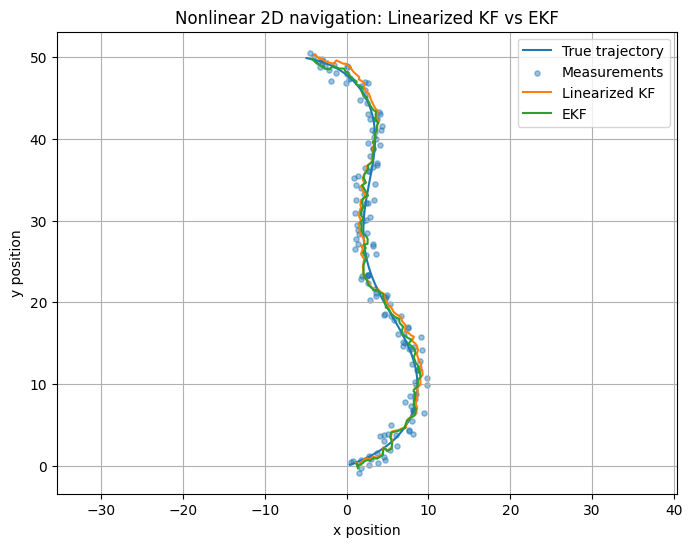

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(true_positions[:, 0], true_positions[:, 1], label="True trajectory")
plt.scatter(measurements[:, 0], measurements[:, 1], s=14, alpha=0.45, label="Measurements")
plt.plot(kf_states[:, 0], kf_states[:, 1], label="Linearized KF")
plt.plot(ekf_states[:, 0], ekf_states[:, 1], label="EKF")

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Nonlinear 2D navigation: Linearized KF vs EKF")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

## 11. Position components over time

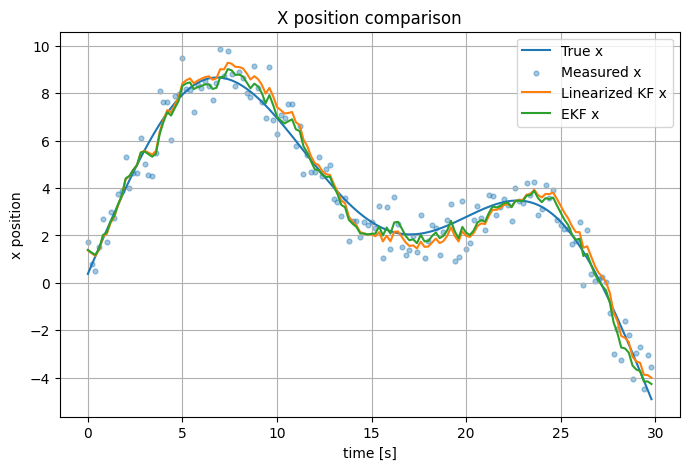

In [26]:
t = np.arange(num_steps) * dt

plt.figure(figsize=(8, 5))
plt.plot(t, true_states[:, 0], label="True x")
plt.scatter(t, measurements[:, 0], s=12, alpha=0.4, label="Measured x")
plt.plot(t, kf_states[:, 0], label="Linearized KF x")
plt.plot(t, ekf_states[:, 0], label="EKF x")
plt.xlabel("time [s]")
plt.ylabel("x position")
plt.title("X position comparison")
plt.grid(True)
plt.legend()
plt.show()

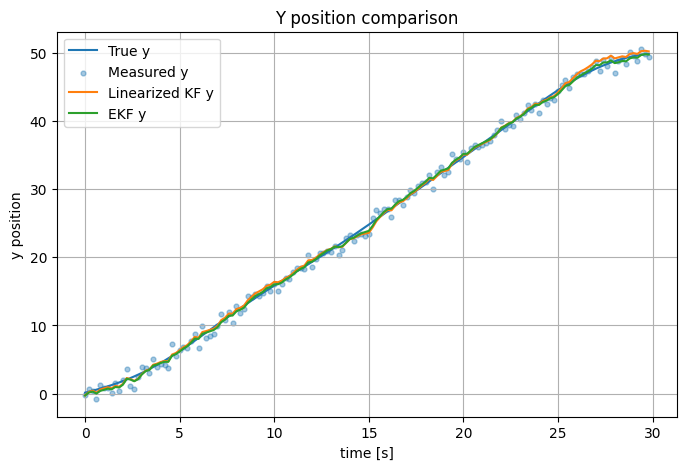

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(t, true_states[:, 1], label="True y")
plt.scatter(t, measurements[:, 1], s=12, alpha=0.4, label="Measured y")
plt.plot(t, kf_states[:, 1], label="Linearized KF y")
plt.plot(t, ekf_states[:, 1], label="EKF y")
plt.xlabel("time [s]")
plt.ylabel("y position")
plt.title("Y position comparison")
plt.grid(True)
plt.legend()
plt.show()

## 12. Heading and speed estimates

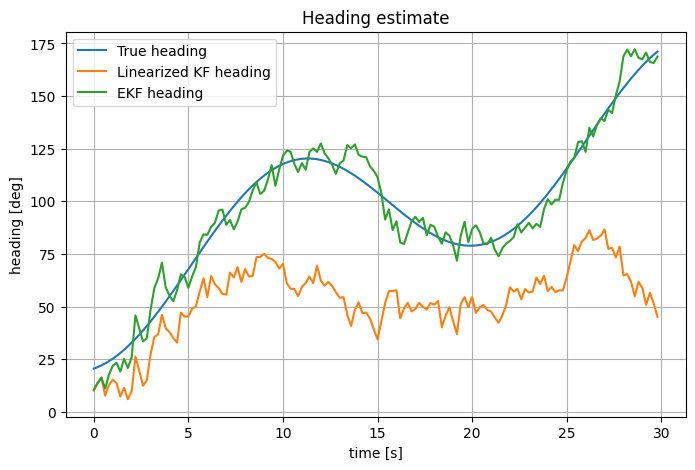

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(t, np.rad2deg(true_states[:, 3]), label="True heading")
plt.plot(t, np.rad2deg(kf_states[:, 3]), label="Linearized KF heading")
plt.plot(t, np.rad2deg(ekf_states[:, 3]), label="EKF heading")
plt.xlabel("time [s]")
plt.ylabel("heading [deg]")
plt.title("Heading estimate")
plt.grid(True)
plt.legend()
plt.show()

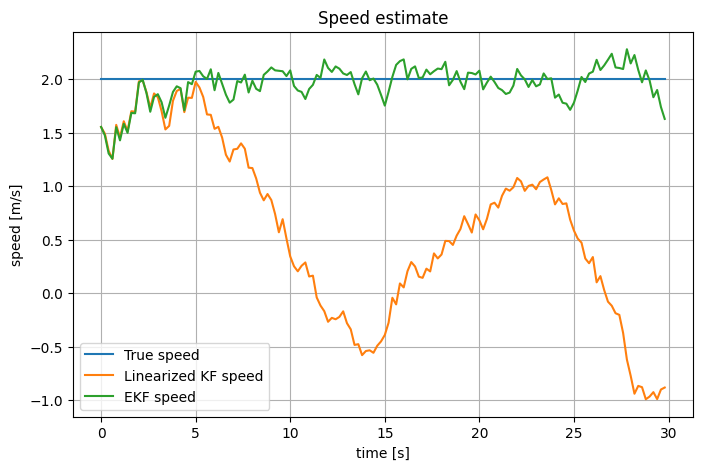

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(t, true_states[:, 2], label="True speed")
plt.plot(t, kf_states[:, 2], label="Linearized KF speed")
plt.plot(t, ekf_states[:, 2], label="EKF speed")
plt.xlabel("time [s]")
plt.ylabel("speed [m/s]")
plt.title("Speed estimate")
plt.grid(True)
plt.legend()
plt.show()

## 13. Quantitative comparison

In [30]:
kf_pos_rmse = np.sqrt(np.mean(np.sum((kf_states[:, :2] - true_positions)**2, axis=1)))
ekf_pos_rmse = np.sqrt(np.mean(np.sum((ekf_states[:, :2] - true_positions)**2, axis=1)))

kf_heading_rmse = np.sqrt(np.mean((wrap_angle(kf_states[:, 3] - true_states[:, 3]))**2))
ekf_heading_rmse = np.sqrt(np.mean((wrap_angle(ekf_states[:, 3] - true_states[:, 3]))**2))

print(f"Linearized KF position RMSE: {kf_pos_rmse:.3f} m")
print(f"EKF position RMSE:           {ekf_pos_rmse:.3f} m")
print()
print(f"Linearized KF heading RMSE: {np.rad2deg(kf_heading_rmse):.3f} deg")
print(f"EKF heading RMSE:           {np.rad2deg(ekf_heading_rmse):.3f} deg")

Linearized KF position RMSE: 0.627 m
EKF position RMSE:           0.487 m

Linearized KF heading RMSE: 49.366 deg
EKF heading RMSE:           6.905 deg


## 14. Discussion

Typical outcome:

- both filters reduce measurement noise,
- the **linearized KF** works reasonably well near the nominal operating point,
- the **EKF** usually performs better once the vehicle turns significantly and the dynamics move away from the fixed linearization.

That is the key lesson:

- A standard linear KF needs a linear model.
- If the real system is nonlinear, you can:
  - linearize once and accept approximation error, or
  - use an EKF and re-linearize as the state evolves.

## 15. Additional things to explore

A few natural extensions:

- make speed change over time too,
- use a nonlinear measurement model such as range/bearing,
- compare EKF with UKF,
- test what happens when the initial heading estimate is poor.